# Homework 1 part 2 - Deep Learning Winter 2024

Student 1: Samih Warwar 324888155

Student 2: Merry Shalabi 324007202

# Question 2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt


transform = transforms.Compose([
    transforms.Resize((224, 224)),  # VGG expects 224x224 images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize like ImageNet
])

# Load the dataset using ImageFolder
train_dataset = datasets.ImageFolder('/content/drive/MyDrive/Deep_learning/data', transform=transform)
test_dataset = datasets.ImageFolder('/content/drive/MyDrive/Deep_learning/Test', transform=transform)

train_size = int(0.8 * len(train_dataset))  # 80% for training
val_size = len(train_dataset) - train_size  # 20% for validation
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

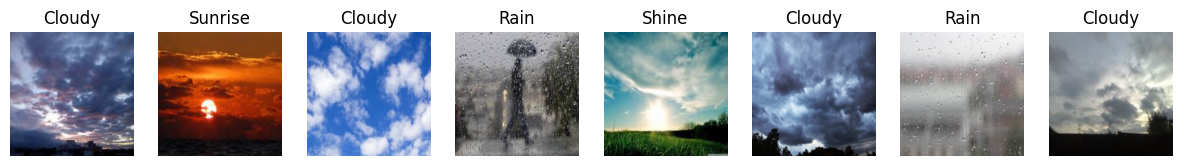

In [ ]:
# Define a function to show images
def show_sample_images(dataset, class_names, num_images=8):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image, label = dataset[i]  # Get image and label
        image = image.permute(1, 2, 0)  # Change from (C, H, W) to (H, W, C)

        # Reverse normalization to display images correctly
        image = image * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
        image = torch.clamp(image, 0, 1)  # Ensure valid range

        axes[i].imshow(image)
        axes[i].set_title(class_names[label])
        axes[i].axis("off")

    plt.show()

# Define class names based on your dataset
class_names = train_dataset.dataset.classes
# Display sample images
show_sample_images(train_dataset, class_names)

In [ ]:
#  Load Pretrained VGG model (VGG16 in this case)
vgg = models.vgg16(pretrained=True)

# Modify the model for feature extraction
# Freeze the VGG layers, except the classifier layer
for param in vgg.parameters():
    param.requires_grad = False


num_features = vgg.classifier[6].in_features
vgg.classifier[6] = nn.Linear(num_features, 4)

# Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg = vgg.to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:07<00:00, 78.6MB/s]


$$
\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{C} y_{i,j} \log \hat{y}_{i,j}
$$

**where:**

- $ N $ is the total number of samples in a batch.  
- $ C $ is the number of classes.  
- $ y_{i,j} $ is the true label (one-hot encoded) for sample $ i $, class $ j $.  
- $ \hat{y}_{i,j} $ is the model's predicted probability for sample $ i $, class $ j $ (from softmax).  


In [ ]:
class MyLossFunction(nn.Module):
    def __init__(self):
        super(MyLossFunction, self).__init__()

    def forward(self, outputs, targets):
        # Ensure outputs are probabilities
        outputs = torch.softmax(outputs, dim=1)

        # Convert targets to one-hot encoding
        targets_one_hot = torch.zeros_like(outputs)
        targets_one_hot.scatter_(1, targets.unsqueeze(1), 1)

        # Compute the custom loss
        loss = -torch.mean(torch.sum(targets_one_hot * torch.log(outputs), dim=1))
        return loss

criterion = MyLossFunction()

In [ ]:
optimizer = optim.Adam(vgg.classifier.parameters(), lr=0.001)  # Only the classifier's parameters will be updated

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    model.train()
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate training accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Record training loss and accuracy
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # Calculate validation accuracy
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # Record validation loss and accuracy
        val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

# Call the training function
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    vgg, train_loader, val_loader, criterion, optimizer, num_epochs=5
)

Epoch [1/5], Train Loss: 0.5509, Train Accuracy: 79.93%, Val Loss: 0.2048, Val Accuracy: 94.37%
Epoch [2/5], Train Loss: 0.1699, Train Accuracy: 94.60%, Val Loss: 0.1451, Val Accuracy: 97.18%
Epoch [3/5], Train Loss: 0.1409, Train Accuracy: 95.77%, Val Loss: 0.1327, Val Accuracy: 95.31%
Epoch [4/5], Train Loss: 0.1239, Train Accuracy: 96.60%, Val Loss: 0.1162, Val Accuracy: 96.71%
Epoch [5/5], Train Loss: 0.1111, Train Accuracy: 96.48%, Val Loss: 0.1081, Val Accuracy: 97.18%


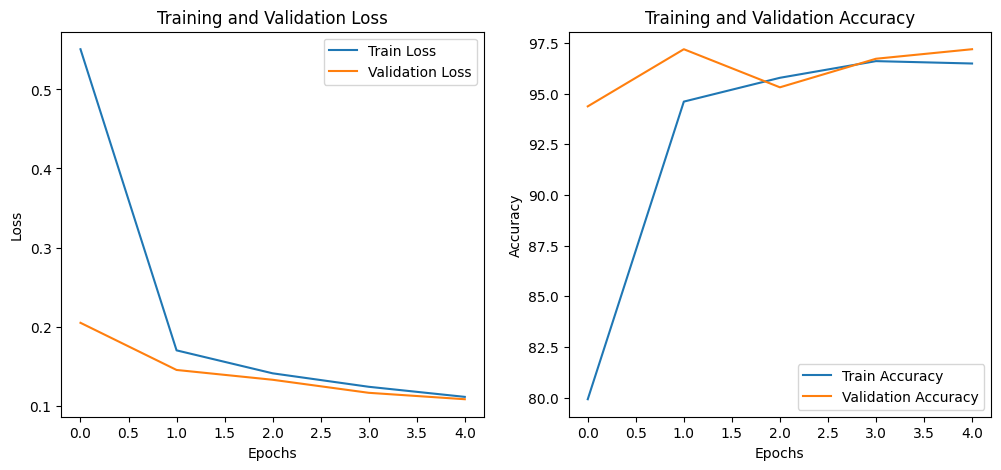

In [ ]:


# Plot training and validation loss and accuracy
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

Test Accuracy: 98.33%


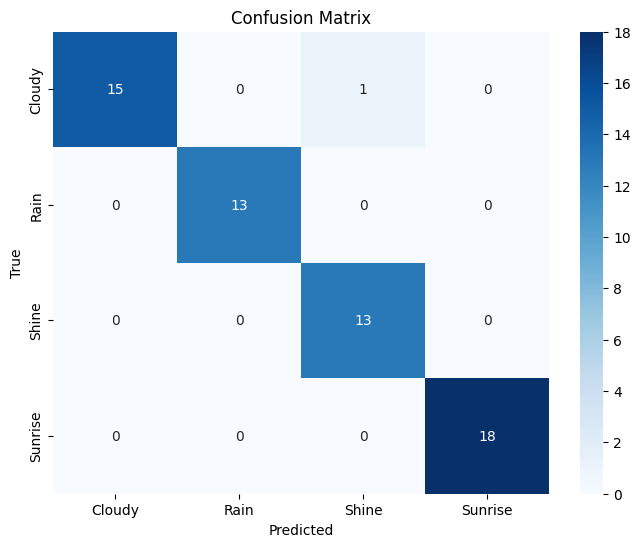

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Evaluate the model on the test set
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Store true and predicted labels for confusion matrix
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Test set accuracy
    test_accuracy = 100 * correct / total
    print(f"Test Accuracy: {test_accuracy:.2f}%")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return y_true, y_pred

# Call the test function
y_true, y_pred = test_model(vgg, test_loader)

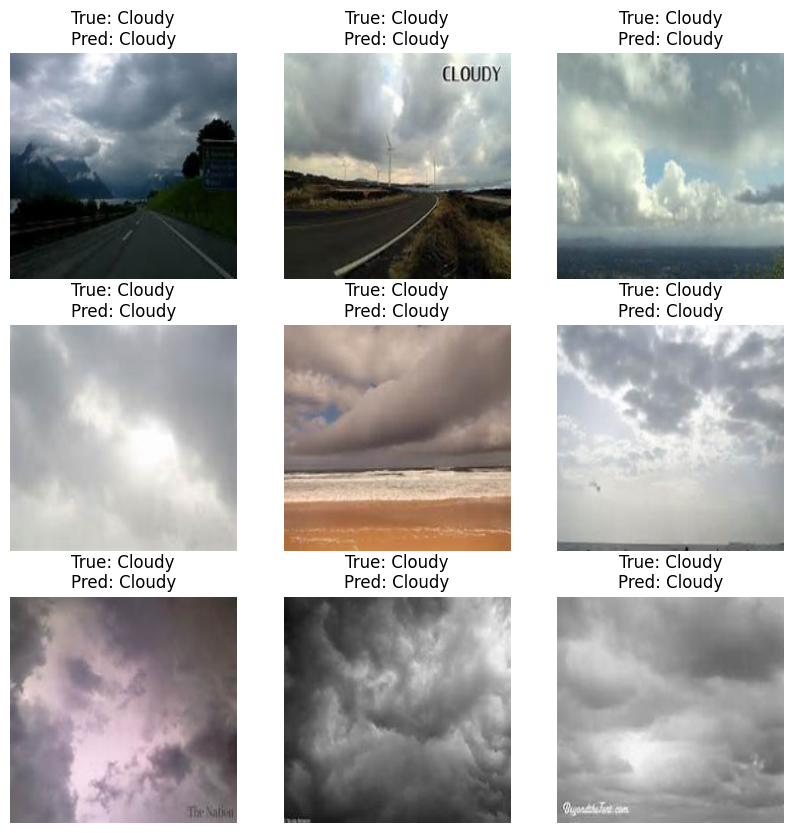

In [ ]:
#  Show a handful of test images with their original and predicted labels
def show_test_images(model, test_loader, class_names, num_images=9):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    # Plot images with true and predicted labels
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(3, 3, i+1)
        img = images[i].cpu().permute(1, 2, 0)
        img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])  # Reverse normalization
        img = torch.clamp(img, 0, 1)  # Clamp to valid range
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted[i]]}")
        plt.axis('off')
    plt.show()

# Show test images
show_test_images(vgg, test_loader, class_names)

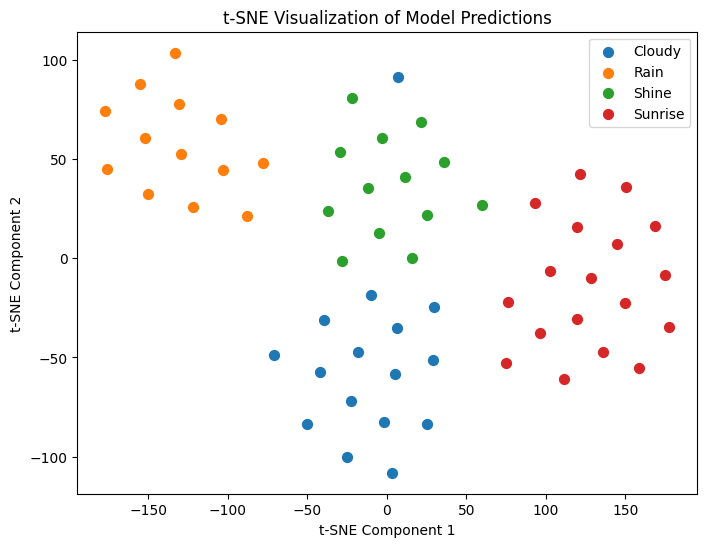

In [ ]:
import numpy as np
from sklearn.manifold import TSNE

def visualize_tsne(model, test_loader, class_names):
    model.eval()
    features = []
    labels = []

    # Extract features and labels from the test set
    with torch.no_grad():
        for images, lbls in test_loader:
            images = images.to(device)
            outputs = model(images)
            features.extend(outputs.cpu().numpy())
            labels.extend(lbls.cpu().numpy())

    # Convert features to a NumPy array
    features = np.array(features)
    labels = np.array(labels)

    # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
    features_2d = tsne.fit_transform(features)

    # Plot the 2D projection
    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        plt.scatter(features_2d[labels == i, 0], features_2d[labels == i, 1], label=class_name, s=50)  # s=50 increases point size
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.title('t-SNE Visualization of Model Predictions')
    plt.legend()
    plt.show()

# Use the entire test set for t-SNE
test_loader_full = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)
visualize_tsne(vgg, test_loader_full, class_names)

In [ ]:
def print_model_details(model):
    print("Model Summary:")
    print(model)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total number of parameters: {total_params}")

# Print the details of the SimpleCNN model
print_model_details(vgg)


Model Summary:
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, paddin

Explanation : <br>
We used VGG, frozed the weights and then did fine-tunning on the weather dataset using a loss function cross entropy after trying some other functions like MSE MAE we found that the CE is better, after finishing the process we tested on the rest of the data and got accuracy 98% which is just one mistake.